# 04_Final_model
## Итоговая модель

##### Импорт модулей

In [28]:
import joblib
import pandas as pd
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

##### Загрузка модели

In [29]:
model = joblib.load('../models/tree/decision_tree_v1.pkl')

features = ['social_media_hours', 'daily_screen_time_hours', 'weekend_screen_time']

#### Примеры работы модели

##### Функция предсказания

In [30]:
def predict_user(model, user_data):
    proba = model.predict_proba(user_data)[0]
    prediction = model.predict(user_data)[0]

    if prediction == 1:
        print("Результат: ЗАВИСИМ")
        print(f"Вероятность зависимости: {proba[1]*100:.1f}%")
    else:
        print("Результат: НЕ ЗАВИСИМ")
        print(f"Вероятность не зависимости: {proba[0]*100:.1f}%")

    return prediction

##### Явно зависимый человек

In [31]:
user1 = pd.DataFrame([[
    6.0,    # social_media_hours
    10.0,   # daily_screen_time_hours
    12.0    # weekend_screen_time
]], columns=features)

print(predict_user(model, user1))

Результат: ЗАВИСИМ
Вероятность зависимости: 100.0%
1


##### Здоровый пользователь

In [32]:
user2 = pd.DataFrame([[
    0.5,    # social_media_hours
    2.0,    # daily_screen_time_hours
    3.0     # weekend_screen_time
]], columns=features)

print(predict_user(model, user2))

Результат: НЕ ЗАВИСИМ
Вероятность не зависимости: 88.2%
0


##### Еще один случай

In [38]:
user3 = pd.DataFrame([[
    2.0,    # social_media_hours
    1.5,    # daily_screen_time_hours
    7.0     # weekend_screen_time
]], columns=features)

predict_user(model, user3)

Результат: НЕ ЗАВИСИМ
Вероятность не зависимости: 82.1%


np.int64(0)

#### Структура дерева

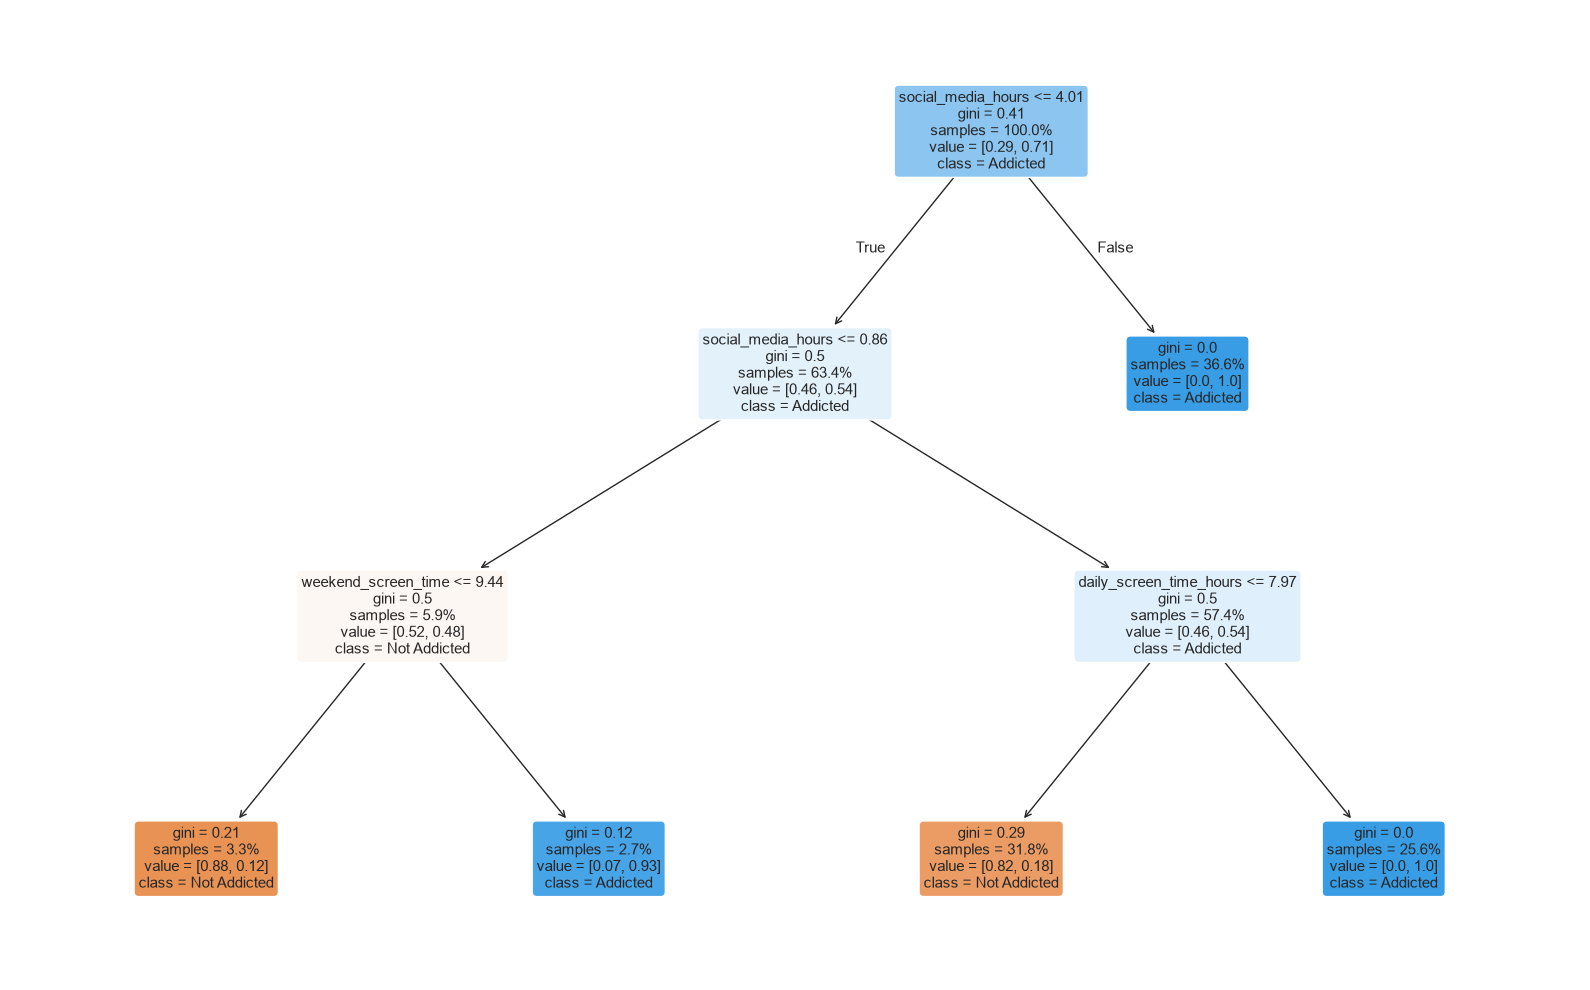

In [39]:
plt.figure(figsize=(16, 10))

plot_tree(
    model,
    feature_names=features,
    class_names=['Not Addicted', 'Addicted'],
    filled=True,
    rounded=True,
    fontsize=11,
    precision=2,
    impurity=True,
    proportion=True
)

plt.title('Структура дерева', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()